In [1]:
from multivae.data.datasets import MHD

In [2]:
dataset = MHD('../../../data/MHD/mhd_test.pt')

torch.Size([1, 28, 28])
torch.Size([1, 32, 128])
tensor([0.4150, 0.4155, 0.4162, 0.4161, 0.4143, 0.4122, 0.4108, 0.4103, 0.4109,
        0.4124, 0.4149, 0.4183, 0.4226, 0.4277, 0.4337, 0.4405, 0.4481, 0.4563,
        0.4652, 0.4746, 0.4843, 0.4944, 0.5046, 0.5148, 0.5249, 0.5347, 0.5442,
        0.5532, 0.5616, 0.5694, 0.5765, 0.5829, 0.5885, 0.5935, 0.5978, 0.6015,
        0.6046, 0.6072, 0.6093, 0.6111, 0.6124, 0.6135, 0.6144, 0.6150, 0.6155,
        0.6159, 0.6162, 0.6164, 0.6165, 0.6166, 0.6167, 0.6168, 0.6168, 0.6168,
        0.6168, 0.6168, 0.6168, 0.6168, 0.6167, 0.6159, 0.6127, 0.6065, 0.5986,
        0.5903, 0.5825, 0.5753, 0.5687, 0.5625, 0.5566, 0.5509, 0.5456, 0.5406,
        0.5359, 0.5318, 0.5281, 0.5249, 0.5222, 0.5200, 0.5182, 0.5167, 0.5156,
        0.5147, 0.5140, 0.5135, 0.5131, 0.5128, 0.5126, 0.5124, 0.5123, 0.5122,
        0.5121, 0.5121, 0.5120, 0.5121, 0.5129, 0.5143, 0.5152, 0.5156, 0.5157,
        0.5158, 0.4297, 0.4299, 0.4301, 0.4302, 0.4297, 0.4294, 0.4293,

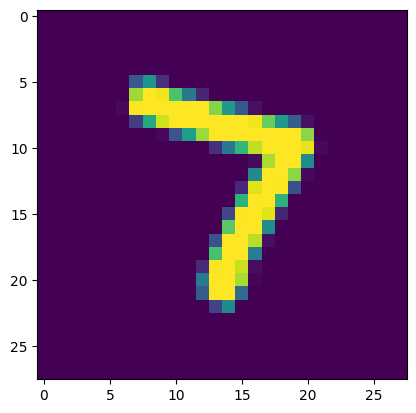

In [4]:
import matplotlib.pyplot as plt
sample = dataset[0]
print(sample.data['image'].shape)
plt.imshow(sample.data['image'][0])
print(sample.data['audio'].shape)
print(sample.data['trajectory'])

print(sample.data['image'].max(), sample.data['image'].min())
print(sample.data['audio'].max(), sample.data['audio'].min())
print(sample.data['trajectory'].max(), sample.data['trajectory'].min())

In [29]:
classifiers_path = '../../../data/MHD/classifiers/'
from architectures import *
import os

classifiers = dict(
    image = Image_Classifier(),
    audio = Sound_Classifier(),
    trajectory = Trajectory_Classifier()
    
)

classifiers['audio'].load_state_dict(torch.load(os.path.join(classifiers_path, 'best_sound_classifier_model.pth.tar'), map_location='cpu')['state_dict'])

<All keys matched successfully>

In [32]:
classifiers['audio'].eval()
torch.argmax(classifiers['audio'](sample.data['audio'].unsqueeze(0)))

tensor(7)